# One asset, two automation futures

An automation arrival may leave labour in production or move the economy to a labour-free AK technology. Before the event, the government does not know which successor will arrive. One installed-equity position then delivers a pair of payoffs—one in each successor—but the government can choose only their common scale.

The central result is dimensional: a single payoff vector generally spans a line in the two-successor space. The current code has not yet produced an admissible transition from the inherited date-zero state, so the notebook reports no policy or welfare magnitude.

## Timing and the two branches

The event is totally inaccessible. Physical capital is continuous when it arrives, and the portfolio chosen just before the event pays before any successor rebalancing. A bounded predictable tax on rental flows has no instantaneous jump payoff.

| Environment | Possible successors | Installed-equity event payoff | Dimension of event risk |
|---|---:|---|---:|
| Fixed-mark benchmark | one | one nonzero scalar gain | one |
| Partial-or-full branch | partial $(P)$ or full $(F)$ | $J=(J_P,J_F)^\top$ | two |

In the fixed-mark benchmark, one nonzero risky payoff spans the one-dimensional event innovation. With two marks, changing the holding $s$ delivers only $sJ$. The two branches also differ in technology and successor support, so their welfare levels are not a controlled counterfactual.

## The residual that one holding cannot reach

Let $u=(u_P,u_F)^\top$ collect the government's fiscal valuation residual across the two successor regimes. Its projection on the installed-equity payoff is

$$
u^\parallel
=
\frac{u^\top J}{J^\top J}J,
\qquad
u^\perp=u-u^\parallel,
\qquad
(u^\perp)^\top J=0.
$$

At an interior portfolio choice, the first-order condition restricts the projection on $J$. It does not impose a separate valuation equality for $P$ and $F$. The arbitrary vectors below make this geometry visible.

| Geometry check | Value |
|---|---:|
| dimension spanned by installed equity | 1 |
| remaining exposure of the residual to that payoff | -2.78e-17 |
| share of the fiscal residual left unspanned | 99.5% |

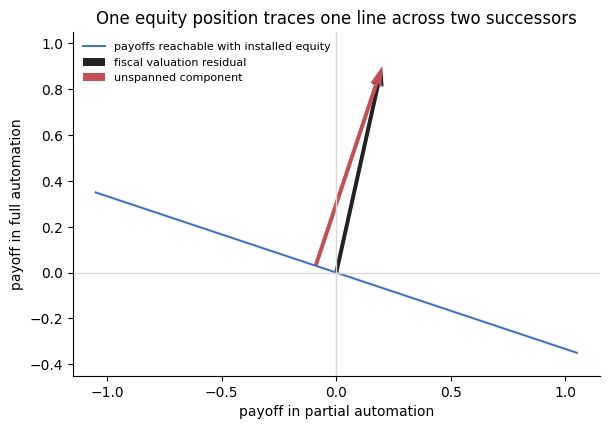

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

payoff = np.array([0.75, -0.25])
fiscal_residual = np.array([0.20, 0.90])
parallel = (fiscal_residual @ payoff) / (payoff @ payoff) * payoff
orthogonal = fiscal_residual - parallel

display(
    Markdown(
        "| Geometry check | Value |\n|---|---:|\n"
        f"| dimension spanned by installed equity | "
        f"{np.linalg.matrix_rank(payoff.reshape(2, 1))} |\n"
        f"| remaining exposure of the residual to that payoff | "
        f"{orthogonal @ payoff:.2e} |\n"
        f"| share of the fiscal residual left unspanned | "
        f"{np.linalg.norm(orthogonal)/np.linalg.norm(fiscal_residual):.1%} |"
    )
)

fig, ax = plt.subplots(figsize=(6.8, 5.4))
scale = np.linspace(-1.4, 1.4, 80)
ax.plot(scale * payoff[0], scale * payoff[1], color="#4472C4",
        label="payoffs reachable with installed equity")
ax.quiver(0, 0, *fiscal_residual, angles="xy", scale_units="xy", scale=1,
          color="#222222", label="fiscal valuation residual")
ax.quiver(*parallel, *orthogonal, angles="xy", scale_units="xy", scale=1,
          color="#C44E52", label="unspanned component")
ax.axhline(0, color="0.85", linewidth=1)
ax.axvline(0, color="0.85", linewidth=1)
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-0.45, 1.05)
ax.set_xlabel("payoff in partial automation")
ax.set_ylabel("payoff in full automation")
ax.set_title("One equity position traces one line across two successors")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## What the implemented stationary algebra contributes

The full-automation precursor solves stationary endpoint relations. If $q$ is the value of installed capital, $\varphi$ governs installation costs, and $\delta$ is depreciation, the investment rate and capital growth satisfy

$$
\iota(q)=\frac{q-1}{\varphi},
\qquad
g(q)=\frac{\log q}{\varphi}-\delta.
$$

The code uses these relations in root searches, fixed-mark compatibility checks, and payoff-rank diagnostics. They are building blocks for the post-event economies. They do not solve the pre-event Ramsey transition or determine a date-zero portfolio.

## Why the current candidate atlas yields no policy figure

The frozen marked-Poisson bundle examines a reduced set of algebraic candidates and applies progressively stronger feasibility checks. The next table is useful because it shows where the computation stops. Candidate counts are not estimates.

In [2]:
import json
from pathlib import Path

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs005_poisson_status_snapshot.json"),
        Path("data/cs005_poisson_status_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))
atlas = snapshot["candidate_atlas"]

lines = [
    "| Candidate check | Count |",
    "|---|---:|",
    f"| algebraic candidates examined | {atlas['candidate_count']} |",
    f"| candidates passing the earlier checks | {atlas['pre_w5_admissible_count']} |",
    f"| candidates passing every current admissibility check | {atlas['fully_admissible_count']} |",
    f"| candidates matching the inherited date-zero state | {atlas['matched_inherited_state_count']} |",
    "",
    f"A separate backward-tail check meets its declared "
    f"{snapshot['pm08_tail_tolerance']:.0e} tolerance: "
    f"**{snapshot['pm08_tail_certificate_pass']}**. "
    "That check covers only its stated post-mark tail.",
]
display(Markdown("\n".join(lines)))

| Candidate check | Count |
|---|---:|
| algebraic candidates examined | 4 |
| candidates passing the earlier checks | 1 |
| candidates passing every current admissibility check | 0 |
| candidates matching the inherited date-zero state | 0 |

A separate backward-tail check meets its declared 1e-08 tolerance: **True**. That check covers only its stated post-mark tail.

None of the four candidates passes every current gate, and none matches the inherited date-zero state. The computation therefore does not license an optimal tax, saving path, portfolio, or welfare comparison. A passing tail calculation for one post-mark domain cannot supply those missing objects.

## What the rank result licenses

With one fixed mark and one nonzero total-gain payoff, the risky claim spans the one-dimensional event innovation. With two marks, one position generically leaves an orthogonal fiscal-valuation residual. This is a statement about the attainable payoff set. It does not establish financing, solvency, admissibility, or a nonzero tax wedge.

The formal asset-and-tax mapping behind this rank statement is recorded as the marked-Poisson incomplete-spanning result (R29) and has not yet passed the project's proof audit. The Brownian and Poisson models use the same geometric idea under different timing, technology, ownership, and pricing closures; their numerical outputs should not be pooled as direct counterfactuals.

## Reproduce and trace

- Marked-Poisson source: [tai-public-finance-poisson at commit 74c736f](https://github.com/Nathan-Barnard/tai-public-finance-poisson/tree/74c736f8753e65f444eb30443a16adbb62f9c35c)
- Run implementation: 5a264b836ecdfd8e22c868b38680ec8435545fc4; run RUN-20260902T220418Z-CS005-5a264b83-01
- Full-automation endpoint source: [tai-public-finance-full-automation at commit 1b1fcd5](https://github.com/Nathan-Barnard/tai-public-finance-full-automation/tree/1b1fcd5932ac591ed20f80b26734f145903f5642)
- Research objects: CP005 and draft specification CS005; frozen export notebooks/data/cs005_poisson_status_snapshot.json
- Environment: upstream uv.lock; Python 3.13 with NumPy, SciPy, and PyYAML

Re-running the documented marked-Poisson entrypoint reproduces the same incomplete diagnostic. It does not promote the candidates into solutions.